In [1]:
#Imports

import numpy as np
import pandas as pd
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import seaborn as sns
from sklearn.metrics import roc_curve
from cycler import cycler
import matplotlib.pyplot as plt

In [2]:
# Configurations

RANDOM_STATE = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

#Paths

DATASET_PATH = "SpamHam SMS cleaned datasets.csv"


np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")

### Dataset was cleaned using a "R" code provided in extra folder

In [3]:
# Load cleaned dataset
df = pd.read_csv(DATASET_PATH)


if "cleaned_text" not in df.columns or "type" not in df.columns:
    raise ValueError(f"Expected columns ['cleaned_text','type'] but got {list(df.columns)}")

X = df["cleaned_text"].astype(str)
y = df["type"].map({"ham": 0, "spam": 1}).astype(int)

print("Rows:", len(df))
print("Spam rate:", y.mean())


Rows: 9645
Spam rate: 0.5002592016588906


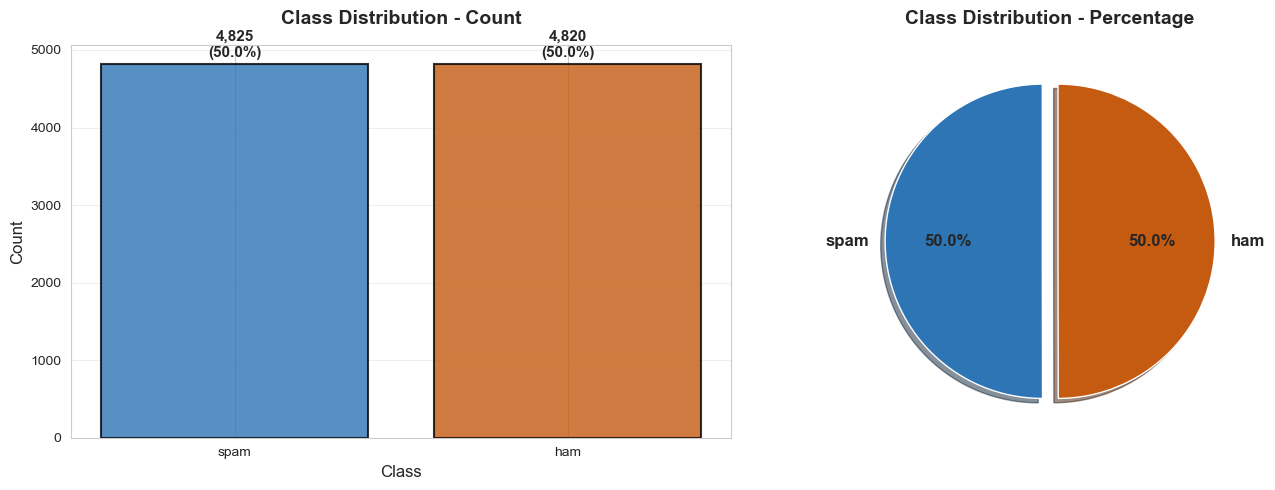

In [4]:
# TODO: Quick EDA (Class Balance Analysis)

# Ensure counts exists
counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2E75B6', '#C55A11']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0].set_title('Class Distribution - Count', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

for i, (idx, val) in enumerate(counts.items()):
    pct = (val / len(df)) * 100
    axes[0].text(i, val + 50, f'{val:,}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
explode = (0.05, 0.05)
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           colors=colors, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'},
           explode=explode, shadow=True)
axes[1].set_title('Class Distribution - Percentage', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()


In [5]:
# Data Splitting


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y
)
val_ratio_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio_adjusted, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")


Train: 6751  Val: 1447  Test: 1447


In [6]:
# Vectorizers for Pipelines: word-level (1-2 grams), char-level (3-5 grams), combined


word_vec = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents="unicode"
)

char_vec = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True
)

word_plus_char = FeatureUnion([
    ("word", word_vec),
    ("char", char_vec),
])


## Models (pipelines)

- **Logistic Regression** as a strong, fast baseline.
- **Linear SVM + calibration** for well-behaved probabilities.
- **ComplementNB** often beats MultinomialNB on imbalanced text.

In [7]:

# Naive Bayes Pipeline That Uses Only Word-level TF-IDF

nb_pipe = Pipeline([
    ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)),
    ("clf", ComplementNB())
])

# SVM and Logistic Regression Pipelines That Use Combined Word+Char TF-IDF


svm_pipe = Pipeline([
    ("vec", word_plus_char),
    ("clf", CalibratedClassifierCV(
        estimator=LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
        method="sigmoid",
        cv=3
    ))
])

lr_pipe = Pipeline([
    ("vec", word_plus_char),
    ("clf", LogisticRegression(
        solver="liblinear",
        class_weight="balanced",
        max_iter=500,
        random_state=RANDOM_STATE
    ))
])


In [8]:
# Hyperparameter Tuning with GridSearchCV and 5-Fold Stratified CV


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

nb_grid = {
    "clf__alpha": [0.02, 0.05, 0.1, 0.2, 0.5]
}

svm_grid = {
    # For CalibratedClassifierCV, base estimator params are accessed via clf__estimator__
    "clf__estimator__C": [0.5, 1.0, 2.0, 4.0]
}

lr_grid = {
    "clf__C": [0.5, 1.0, 2.0, 4.0]
}

def tune(pipe, grid, name):
    gs = GridSearchCV(
        pipe, grid, scoring="f1", cv=cv, n_jobs=-1, verbose=0
    )
    gs.fit(X_train, y_train)
    print(f"{name}: best params = {gs.best_params_} | best CV F1 = {gs.best_score_:.4f}")
    return gs.best_estimator_

t0 = time.time()
nb_best = tune(nb_pipe, nb_grid, "ComplementNB")
svm_best = tune(svm_pipe, svm_grid, "Calibrated LinearSVC")
lr_best = tune(lr_pipe, lr_grid, "LogReg")
print("Tuning time:", round(time.time() - t0, 2), "s")


ComplementNB: best params = {'clf__alpha': 0.05} | best CV F1 = 0.9562


c:\Users\NTC\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\NTC\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\NTC\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Calibrated LinearSVC: best params = {'clf__estimator__C': 2.0} | best CV F1 = 0.9843
LogReg: best params = {'clf__C': 4.0} | best CV F1 = 0.9809
Tuning time: 64.62 s


In [9]:
# Fit tuned models on train+val (then evaluate once on test)
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

nb_best.fit(X_trainval, y_trainval)
svm_best.fit(X_trainval, y_trainval)
lr_best.fit(X_trainval, y_trainval)

# Soft voting ensemble
ensemble = VotingClassifier(
    estimators=[("nb", nb_best), ("svm", svm_best), ("lr", lr_best)],
    voting="soft",
    weights=[1, 2, 2],   # starting point; we tune threshold below
    n_jobs=-1
)
ensemble.fit(X_trainval, y_trainval)


c:\Users\NTC\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\NTC\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\NTC\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


VotingClassifier(estimators=[('nb',
                              Pipeline(steps=[('vec',
                                               TfidfVectorizer(max_df=0.95,
                                                               min_df=2,
                                                               ngram_range=(1,
                                                                            2),
                                                               sublinear_tf=True)),
                                              ('clf',
                                               ComplementNB(alpha=0.05))])),
                             ('svm',
                              Pipeline(steps=[('vec',
                                               FeatureUnion(transformer_list=[('word',
                                                                               TfidfVectorizer(max_df=0.95,
                                                                                               min_df=2,
                                                                                               ngram_range=(1,
                                                                                                            2),
                                                                                               strip_accents='unicode',
                                                                                               sublinear_tf=True)),
                                                                              ('char',
                                                                               Tfidf...
                                               FeatureUnion(transformer_list=[('word',
                                                                               TfidfVectorizer(max_df=0.95,
                                                                                               min_df=2,
                                                                                               ngram_range=(1,
                                                                                                            2),
                                                                                               strip_accents='unicode',
                                                                                               sublinear_tf=True)),
                                                                              ('char',
                                                                               TfidfVectorizer(analyzer='char_wb',
                                                                                               min_df=2,
                                                                                               ngram_range=(3,
                                                                                                            5),
                                                                                               sublinear_tf=True))])),
                                              ('clf',
                                               LogisticRegression(C=4.0,
                                                                  class_weight='balanced',
                                                                  max_iter=500,
                                                                  random_state=42,
                                                                  solver='liblinear'))]))],
                 n_jobs=-1, voting='soft', weights=[1, 2, 2])

In [10]:
# Threshold tuning on the validation set BEFORE we merged train+val (for honesty)
# We'll re-fit quickly on TRAIN only, then tune threshold on VAL, then re-fit on train+val for final test.

def fit_all_on(Xtr, ytr):
    nb = nb_best.fit(Xtr, ytr)
    svm = svm_best.fit(Xtr, ytr)
    lr = lr_best.fit(Xtr, ytr)
    ens = VotingClassifier(
        estimators=[("nb", nb), ("svm", svm), ("lr", lr)],
        voting="soft",
        weights=[1, 2, 2],
        n_jobs=-1
    ).fit(Xtr, ytr)
    return ens

ens_for_threshold = fit_all_on(X_train, y_train)
val_proba = ens_for_threshold.predict_proba(X_val)[:, 1]

# Choose threshold maximizing accuracy (swap to F1 if your grading cares more about F1)
thresholds = np.linspace(0.05, 0.95, 181)
accs = [accuracy_score(y_val, (val_proba >= t).astype(int)) for t in thresholds]
best_t = float(thresholds[int(np.argmax(accs))])
print("Best threshold on VAL (accuracy):", best_t, "VAL acc:", max(accs))

# Final re-fit on train+val and evaluate on test using that threshold
ensemble_final = VotingClassifier(
    estimators=[("nb", nb_best), ("svm", svm_best), ("lr", lr_best)],
    voting="soft",
    weights=[1, 2, 2],
    n_jobs=-1
).fit(X_trainval, y_trainval)

test_proba = ensemble_final.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_t).astype(int)

print("\nTEST RESULTS (threshold tuned):")
print("Accuracy :", round(accuracy_score(y_test, test_pred), 4))
print("Precision:", round(precision_score(y_test, test_pred), 4))
print("Recall   :", round(recall_score(y_test, test_pred), 4))
print("F1       :", round(f1_score(y_test, test_pred), 4))
print("AUC      :", round(roc_auc_score(y_test, test_proba), 4))
print("\nConfusion matrix:\n", confusion_matrix(y_test, test_pred))
print("\nReport:\n", classification_report(y_test, test_pred, target_names=["Ham","Spam"]))


c:\Users\NTC\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\NTC\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\NTC\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Best threshold on VAL (accuracy): 0.49999999999999994 VAL acc: 0.9861782999308915

TEST RESULTS (threshold tuned):
Accuracy : 0.9848
Precision: 0.9902
Recall   : 0.9793
F1       : 0.9847
AUC      : 0.9977

Confusion matrix:
 [[716   7]
 [ 15 709]]

Report:
               precision    recall  f1-score   support

         Ham       0.98      0.99      0.98       723
        Spam       0.99      0.98      0.98       724

    accuracy                           0.98      1447
   macro avg       0.98      0.98      0.98      1447
weighted avg       0.98      0.98      0.98      1447



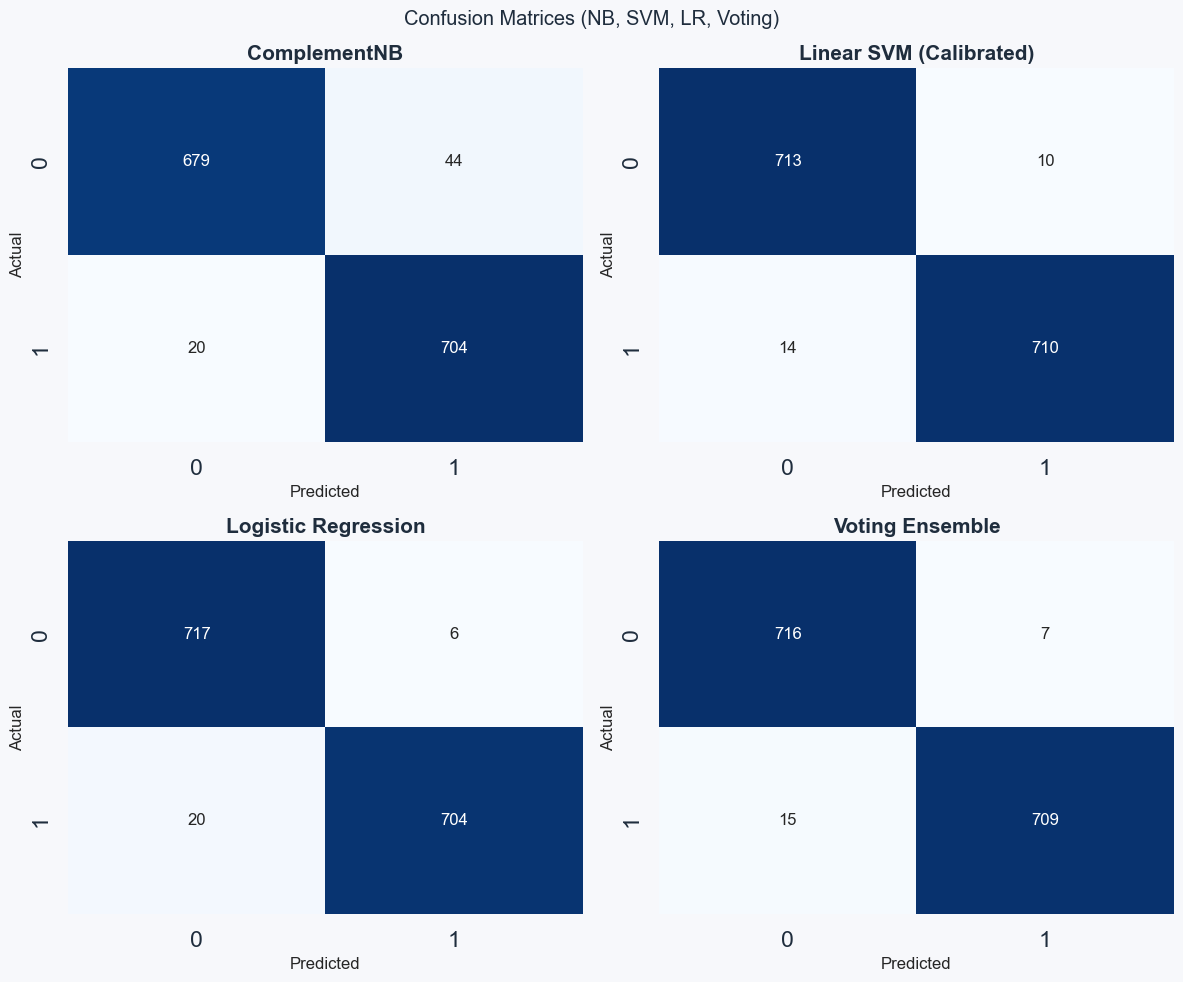

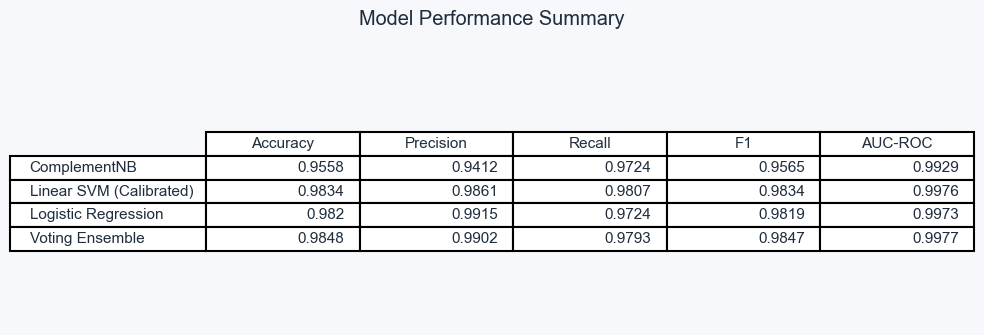

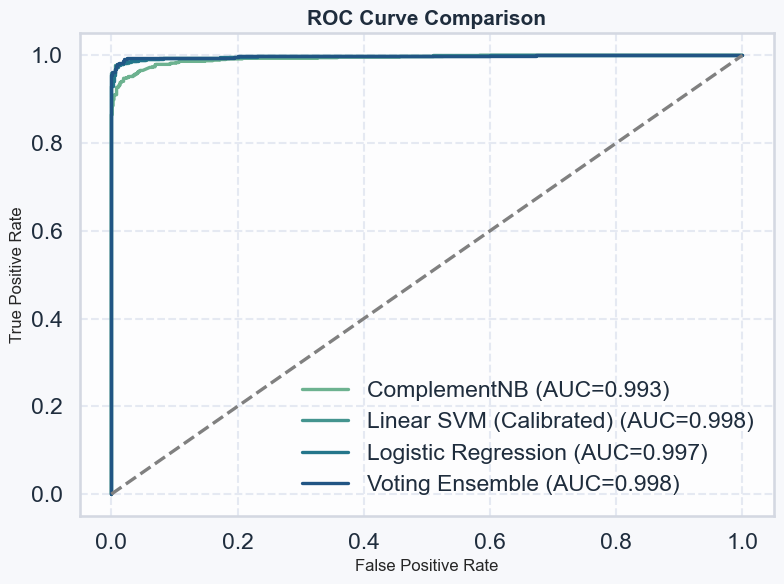

In [11]:
# Visualizations of Results

model_defs = [
    ("ComplementNB", nb_best, 0.5),
    ("Linear SVM (Calibrated)", svm_best, 0.5),
    ("Logistic Regression", lr_best, 0.5),
    ("Voting Ensemble", ensemble_final, best_t),
]

metrics_rows, confusions, roc_points = [], {}, {}

for name, model, thresh in model_defs:
    proba = model.predict_proba(X_test)[:, 1]
    preds = (proba >= thresh).astype(int)
    cm = confusion_matrix(y_test, preds)
    confusions[name] = cm
    metrics_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "AUC-ROC": roc_auc_score(y_test, proba),
    })
    roc_points[name] = roc_curve(y_test, proba)
    model_order = [name for name, _, _ in model_defs]
    primary_palette = sns.color_palette("crest", len(model_defs))

    sns.set_theme(
        style="white",
        context="talk",
        palette=primary_palette,
        rc={
            "axes.facecolor": "#FDFDFE",
            "figure.facecolor": "#F7F8FB",
            "axes.edgecolor": "#D4D8E2",
            "grid.color": "#E5E9F2",
            "grid.linestyle": "--",
        }
    )

    plt.rcParams.update({
        "axes.titleweight": "bold",
        "axes.titlesize": 15,
        "axes.labelsize": 12,
        "axes.grid": True,
        "legend.frameon": False,
        "font.size": 12,
        "lines.linewidth": 2.4,
        "xtick.color": "#1F2D3D",
        "ytick.color": "#1F2D3D",
        "text.color": "#1F2D3D",
    })

    plt.rcParams["axes.prop_cycle"] = cycler(color=primary_palette)
fig_cm, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, cm) in zip(axes.flat, confusions.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
fig_cm.suptitle("Confusion Matrices (NB, SVM, LR, Voting)")
fig_cm.tight_layout()

metrics_df = pd.DataFrame(metrics_rows).set_index("Model").round(4)
fig_table, ax_table = plt.subplots(figsize=(10, 1 + 0.6 * len(metrics_df)))
ax_table.axis("off")
table = ax_table.table(
    cellText=metrics_df.values,
    rowLabels=metrics_df.index,
    colLabels=metrics_df.columns,
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.4)
fig_table.suptitle("Model Performance Summary")
fig_table.tight_layout()

fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
for name, (fpr, tpr, _) in ((n, roc_points[n]) for n in metrics_df.index):
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC={metrics_df.loc[name, 'AUC-ROC']:.3f})")
ax_roc.plot([0, 1], [0, 1], "--", color="gray")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve Comparison")
ax_roc.legend()
fig_roc.tight_layout()